In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [3]:
import numpy as np 
df.replace(-999, np.nan, inplace=True)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [4]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,1


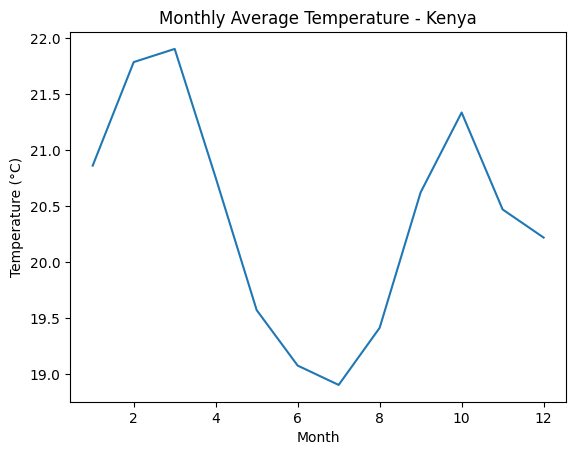

In [5]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Insight: Monthly Average Temperature - Kenya

The trend shows **seasonal oscillations** rather than extreme shifts.  
- **Peak warmth** occurs around March (~22 °C) and again in October.  
- **Coolest period** is mid-year (June–July, ~19 °C).  
- Overall, the range is narrow (19–22 °C), reflecting Kenya’s **equatorial stability**.  

Key takeaway: Kenya’s climate is mild and consistent, with rainfall cycles driving seasonal impacts.


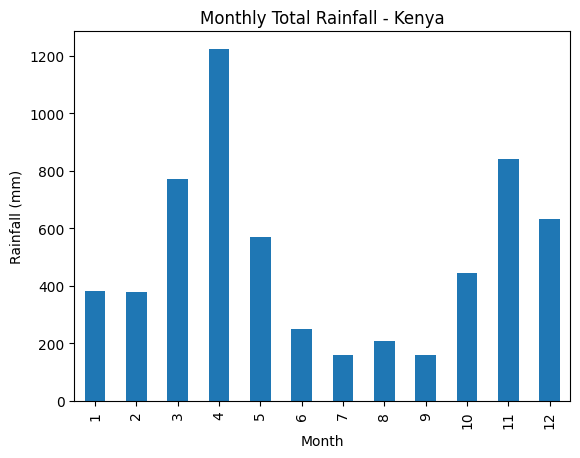

In [6]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall - Kenya")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### Insight: Monthly Total Rainfall - Kenya

Kenya’s climate shows **two rainy seasons**:  
- 🌧️ **Long rains** peak in April (>1200 mm), marking the wettest period.  
- 🌦️ **Short rains** occur in November, with moderate totals.  
- ☀️ **Dry spells** dominate July and September (<200 mm).  

 Key takeaway: Agricultural cycles and water availability are shaped more by rainfall seasonality than temperature variation.


In [7]:
extreme_days = df[df["T2M_MAX"] > 35]
len(extreme_days)


0

### Insight: Extreme Temperature Days - Kenya

Kenya’s climate data shows **0 extreme temperature days** across the year.  
- 🌡️ No days exceed critical heat thresholds.   
- 🔄 This reinforces the **equatorial stability**: temperatures remain mild and consistent.  


In [8]:
df.to_csv("../data/kenya_clean.csv", index=False)